In [1]:
#MOana specific
import os, subprocess
print("PID:", os.getpid())
print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))
print("hostname:", subprocess.run(["hostname"], capture_output=True, text=True).stdout.strip())
print(subprocess.run(["nvidia-smi", "-L"], capture_output=True, text=True).stdout)


PID: 718828
CUDA_VISIBLE_DEVICES: None
hostname: b9229902d877
Failed to initialize NVML: Unknown Error



In [2]:

#MOANA ONLY
#os.environ["CUDA_VISIBLE_DEVICES"] = "1"
#check for errors
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [26]:
# Cell 0 — CONFIG
from pathlib import Path
import numpy as np
%load_ext autoreload
%autoreload 2
import sys, os
from dotenv import load_dotenv
if sys.platform == "win32":
    project_root = Path(r"F:/MScPROJECT_LOCAL")
else:
    _linux_candidates = [Path("/knuckles_drive"), Path("/workspaces/MScPROJECT_LOCAL")]
    for _candidate in _linux_candidates:
        if _candidate.exists():
            project_root = _candidate
            break
    else:
        sys.path.insert(0, str(Path.cwd() / "src"))  # ensure A_Config is importable before project_root is known
        from A_Config import REPO_ROOT
        project_root = Path(REPO_ROOT)  # robust fallback -- REPO_ROOT is computed from A_Config.py's own location, so it's correct on any machine/mount
print(project_root, project_root.exists())
load_dotenv(project_root / ".env")
case_name = "01_walk"
experiment = "01_walk_sparse_50_02_full"
Question = "Where is the first cat in this video?"

asset_name = f"{case_name}_{experiment}"

sys.path.insert(0, str(project_root / "src")) # added for bufflehead
from A_Config import set_case
set_case(case_name, experiment)


#These neeed work
case_dir     = project_root / "Data" / case_name
source_dir   = case_dir     / "010_source"
query_dir    = case_dir     / "012_Gemini_outputs"
yolo_masks_dir = case_dir   / "015_YOLO" / experiment
#temp delete sub folder
frames_for_cam_poses = case_dir / "020_frames_for_cam_poses" 
frames_for_recon   = case_dir   / "020_frames_for_recon" / experiment 
VGGT_O_output_dir   = case_dir   /"035_VGGT_O_output"/experiment
predictions_path =  case_dir   /  VGGT_O_output_dir /"predictions.npz" 
CUT3R_output_dir    = case_dir   /"035_CUT3R_output" / experiment
ply_dir             =   VGGT_O_output_dir  /"ply"        
print("ply_dir",ply_dir ) 
#temp - need to sort out a unified place? no visualisation is justfor me
reg_dir        = case_dir     / "030_Registrations"
csv_path_GPS = case_dir     / "000_GPS_Data" / "GPS_tags_50_02.csv"
csv_path_pose = reg_dir    /"Registration_reality_scan"/"01_walk_sparse_50_02_full_02" /"01_walk_sparse_50_02_FULL_02.csv"


FRAME_NAME_FMT = "{:04d}.jpg"

#TEMP
#This needs to be filed after user input decides on what to analyse
ppt_template = '03_Version_1'

# video loading
# Auto-find the video in 010_source
videos = list(source_dir.glob("*.mp4"))
assert len(videos) == 1, f"Expected 1 video, found {len(videos)}: {videos}"
video_path = videos[0]
print(f"Case    : {case_name}")
print(f"Video   : {video_path.name}")

#reporting
from C_CSV_report import add_to_report
overview = {
    "Video_name"      : video_path.name, 
    "Title"      : f"{case_name}_{experiment}"
}
add_to_report(overview)
api_key = os.getenv("STREETVIEW_API_KEY")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
/workspaces/knuckles_drive True
ply_dir /workspaces/knuckles_drive/Data/01_walk/035_VGGT_O_output/01_walk_sparse_50_02_full/ply
Case    : 01_walk
Video   : VID_20260429_153616750.mp4


A,B 25 25


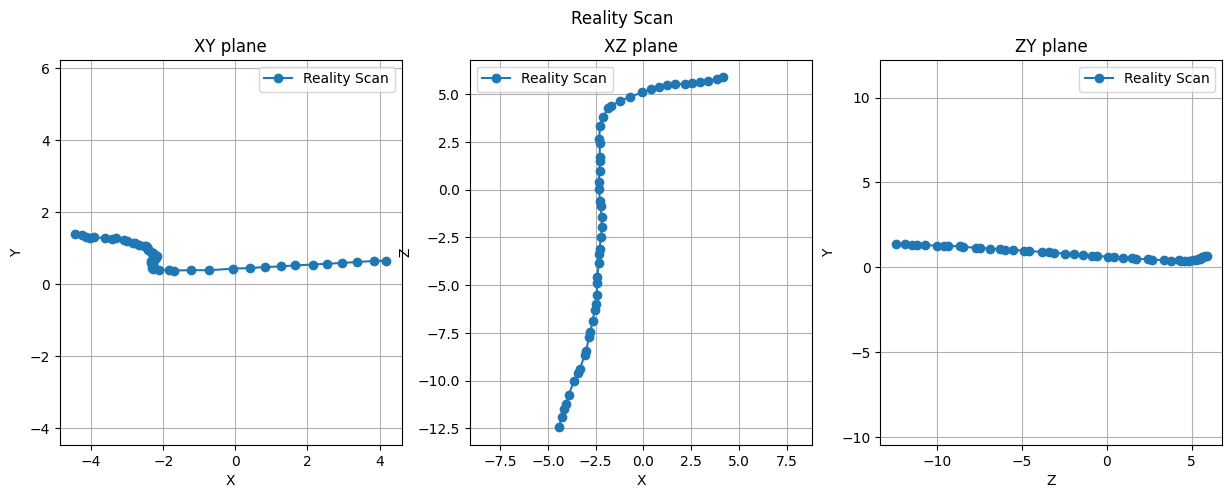

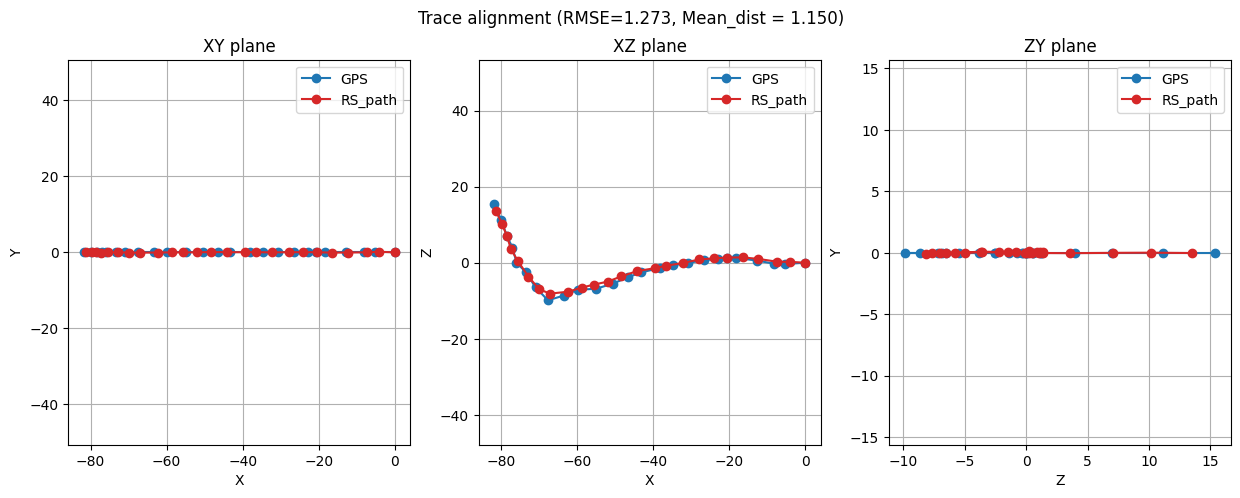

In [11]:
#convert CAMERA POSES from RS model-world-space (set to CAM0) into real-world-space 
#get lat lon positions
#get transforms to convert other things too
from Q_Metric_georeferencing import model_to_GPS_calibrated_locations
cam_poses_realworld_dict, cam_latlons, R_cw, s_cw, t_cw, lat_0, lon_0 = model_to_GPS_calibrated_locations (csv_path_GPS, csv_path_pose)


In [13]:
#LOAD VGGT_O recon for further processing

from F_post_recon_processing import Reconstruction
recon = Reconstruction.load(frames_for_recon, predictions_path, FRAME_NAME_FMT)


A,B 50 50
Subject VGGT-O → real-world: 50 pairs, RMSE = 0.5429 m


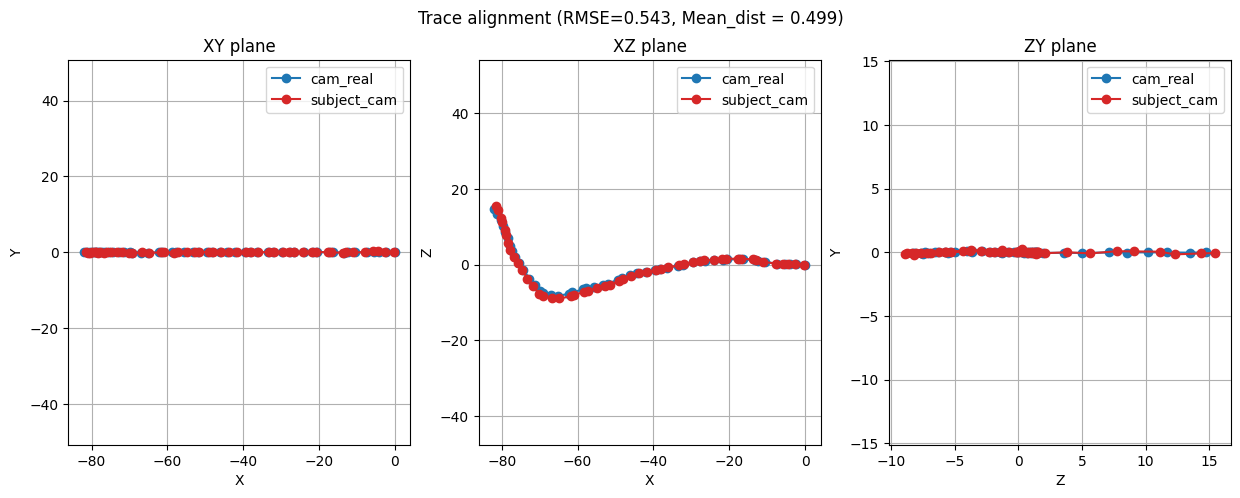

In [34]:
#processes spatial information about the recon and the cubject  - for report and generates the data needed to map the subject
#Takes the lat and long to do mapping
#Takes the cam poses dict to conform the 3d model to the same space that the cam pose transform is in
from Q_subject_analysis import subject_to_metric_and_gps_space
from G_transforms_alignments import  recon_to_recon_transform
R_mw , s_mw, t_mw  = recon_to_recon_transform(recon ,  cam_poses_realworld_dict)



#MAKE PLYS of VGGT__O
#turn VGGT_O output into cam0 space then scale it to metres using the output from subject_to_metric_and_gps_space
#n.b it translates to the beginning of the camera track solve, then re-translates to the recon cam 0 space. 
_ = recon.VGGT_O_preds_to_ply_export(VGGT_O_output_dir  / "ply" ,conf_threshold = 10, R=R_mw, t=t_mw, s=s_mw)
        


In [ ]:
# Cell — PLY visualisation
import importlib, sys
sys.path.insert(0, str(project_root / "src"))
import Thr3D.F_cut3r_vis
importlib.reload(Thr3D.F_cut3r_vis)
from Thr3D.F_cut3r_vis import visualise_cut3r

visualisation_dir = case_dir   /  VGGT_O_output_dir
#visualisation_dir = case_dir   /  CUT3R_output_dir
visualise_cut3r(visualisation_dir)

Found 50 PLY files


╭────── viser (listening *:8081) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8081   │
│   Websocket │ ws://localhost:8081     │
│             ╵                         │
╰───────────────────────────────────────╯

(viser) Connection opened (0, 1 total), 20 persistent messages

In [36]:
from U_rendering import BEV_render

BEV_render = BEV_render(
        ply_dir,
        "VGGT_O",
        pattern="*.ply",
        width=1920,
        height=1080,
        margin_frac=0.05,#fraction of the fitted extent left as empty border on each side
        splat_radius=2,
        camera_forward=(0.0, -1.0, 0.0),#looking straight down -Y
        camera_up=(0.0, 0.0, -1.0),#defines which world direction is "up" in the frame (north)
        background_color=(30, 30, 30),
    )


In [32]:
#make animated map -- always writes an image sequence to assets/map_frames
# (the standard hand-off to the editor); gif/mp4 below are optional extra
# exports of the same frames. Duration is read from the Producer's MAP beat
# inside R_map_animator.main() itself, not passed in here.
if flags["GOOGLE_MAP"] == True:
    import R_map_animator

    R_map_animator.main(
        traces=[
            {"coords": cam_latlons, "trail_color": "#3498db"},#cameras
            {"coords": sub_latlon,    "trail_color": "#e74c3c"},#subject
        ],
        api_key     = api_key,
        gif = True,
        mp4 = None
        

    )
else:
    print("Cell disabled")

NameError: name 'flags' is not defined

In [ ]:
if flags["PROJECTION_MAP"] == True:
    #2D projection mapping of subject to a selected view
    from E_post_recon_processing import Reconstruction
    from P_projection_mapping import projection_mapping_sequence
    from B_video_processing import available_frames
    
    #Use this to project every frame in the recon
    extra_indices = available_frames(frames_for_recon, FRAME_NAME_FMT)
    print(extra_indices)
    
    
    if MULTI_PART_RECON == True:
      recon = recons
      point_cloud_xforms = point_cloud_xforms
    else: 
      recon = recon
      point_cloud_xforms = None
    subject_positions = projection_mapping_sequence(
        
        recon         = recon,
        main_idx      = 3908,
        extra_indices = range (3854,4397),
          #other syntax  [400,4027, 4052, 4065],
          #extra_indices = [extra_indices], - for composite (double [[]])
        masks_dir     = str(yolo_masks_dir),
        point_cloud_xforms = point_cloud_xforms

        new_view = ext ,
        
        confidence_threshold = 2
       
       )
else:
    print("Cell disabled")

ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_h_env_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_plac --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libop

In [ ]:
#render projection of 3D points clouds
from U_rendering import basic_point_cloud_render
#double way to get vggt and cut3r
if flags["VGGT_O_RECON"] ==True:
    visualisation_dir = case_dir   /  VGGT_O_output_dir 
    model = "VGGT_O"
   

    ply_dir = visualisation_dir / "ply"
    print(ply_dir)
    basic_point_cloud_render(
        ply_dir, model    )
    # report metric name = render name, one row per output asset (path relative to
    


/workspaces/MScPROJECT_LOCAL/Data/07_Tropea_cafe/035_VGGT_O_output/cat_03/ply
/workspaces/knuckles_drive/Data/07_Tropea_cafe/090_assets/PC_render_frames_VGGT_O


ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_h_env_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_plac --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libop